In [34]:
import numpy as np
np.random.seed(0)

In [35]:
A = np.array([
    [1, 1, 1, 1],
    [1, 1, 0, 0],
    [1, 0, 1, 1],
    [1, 0, 1, 1]
])

A

array([[1, 1, 1, 1],
       [1, 1, 0, 0],
       [1, 0, 1, 1],
       [1, 0, 1, 1]])

for `X` we generate a random matrix of node features using:

In [36]:
X = np.random.uniform(-1, 1, (4, 4))
X

array([[ 0.09762701,  0.43037873,  0.20552675,  0.08976637],
       [-0.1526904 ,  0.29178823, -0.12482558,  0.783546  ],
       [ 0.92732552, -0.23311696,  0.58345008,  0.05778984],
       [ 0.13608912,  0.85119328, -0.85792788, -0.8257414 ]])

The next step is to define our weight matrices. Indeed, in graph attention layers, there are two
of them: the regular weight matrix `W` , and the attention weight matrix `W_att` . There are different
ways to initialize them (Xavier or He initialization, for example), but we can just reuse the same
random function in this example.
The matrix has to be carefully designed as its dimensions are (# of hidden dimensions, # of nodes)
Notice that # of nodes = 4 is already fixed because it represents the number of nodes in . On
the contrary, the value of # of hidden dimensions is arbitrary: we’ll choose 2 in this example:

In [37]:
W = np.random.uniform(-1, 1, (2, 4))
W

array([[-0.95956321,  0.66523969,  0.5563135 ,  0.7400243 ],
       [ 0.95723668,  0.59831713, -0.07704128,  0.56105835]])

this attention matrix is applied to the concatenation of hdiden vectors to produce a unique value. Thus, its size needs to be (1, dim_h * 2)

In [38]:
W_att = np.random.uniform(-1, 1, (1, 4))
W_att

array([[-0.76345115,  0.27984204, -0.71329343,  0.88933783]])

we want to concatenate hidden vectors from source and destination nodes. A simple way to obtain pairs of source and destination nodes is to look at our adjacency matrix A in COO format: rows store source nodes, and columns store destination nodes. 

In [39]:
connections = np.where(A > 0)
connections

(array([0, 0, 0, 0, 1, 1, 2, 2, 2, 3, 3, 3], dtype=int64),
 array([0, 1, 2, 3, 0, 1, 0, 2, 3, 0, 2, 3], dtype=int64))

we can then concatenate hidden vectors of source and destination nodes using:

In [40]:
np.concatenate([(X @ W.T)[connections[0]], (X @ W.T)[connections[1]]], axis = 1)

array([[ 0.37339233,  0.38548525,  0.37339233,  0.38548525],
       [ 0.37339233,  0.38548525,  0.85102612,  0.47765279],
       [ 0.37339233,  0.38548525, -0.67755906,  0.73566587],
       [ 0.37339233,  0.38548525, -0.65268413,  0.24235977],
       [ 0.85102612,  0.47765279,  0.37339233,  0.38548525],
       [ 0.85102612,  0.47765279,  0.85102612,  0.47765279],
       [-0.67755906,  0.73566587,  0.37339233,  0.38548525],
       [-0.67755906,  0.73566587, -0.67755906,  0.73566587],
       [-0.67755906,  0.73566587, -0.65268413,  0.24235977],
       [-0.65268413,  0.24235977,  0.37339233,  0.38548525],
       [-0.65268413,  0.24235977, -0.67755906,  0.73566587],
       [-0.65268413,  0.24235977, -0.65268413,  0.24235977]])

In [41]:
a = W_att @ np.concatenate([(X @ W.T)[connections[0]], (X @ W.T)[connections[1]]], axis=1).T
a

array([[-0.1007035 , -0.35942847,  0.96036209,  0.50390318, -0.43956122,
        -0.69828618,  0.79964181,  1.8607074 ,  1.40424849,  0.64260322,
         1.70366881,  1.2472099 ]])

In [42]:
def leaky_relu(x, alpha = 0.2):
    return np.maximum(alpha * x, x)

In [43]:
e = leaky_relu(a)
e

array([[-0.0201407 , -0.07188569,  0.96036209,  0.50390318, -0.08791224,
        -0.13965724,  0.79964181,  1.8607074 ,  1.40424849,  0.64260322,
         1.70366881,  1.2472099 ]])

In [44]:
E = np.zeros(A.shape)
E[connections[0], connections[1]] = e[0]
E

array([[-0.0201407 , -0.07188569,  0.96036209,  0.50390318],
       [-0.08791224, -0.13965724,  0.        ,  0.        ],
       [ 0.79964181,  0.        ,  1.8607074 ,  1.40424849],
       [ 0.64260322,  0.        ,  1.70366881,  1.2472099 ]])

In [45]:
def softmax2D(x, axis):
    e = np.exp(x - np.expand_dims(np.max(x, axis=axis), axis))
    sum = np.expand_dims(np.sum(e, axis=axis), axis)
    return e / sum

W_alpha = softmax2D(E, 1)
W_alpha

array([[0.15862414, 0.15062488, 0.42285965, 0.26789133],
       [0.24193418, 0.22973368, 0.26416607, 0.26416607],
       [0.16208847, 0.07285714, 0.46834625, 0.29670814],
       [0.16010498, 0.08420266, 0.46261506, 0.2930773 ]])

In [46]:
H = A.T @ W_alpha @ X @ W.T
H

array([[-1.10126376,  1.99749693],
       [-0.33950544,  0.97045933],
       [-1.03570438,  1.53614075],
       [-1.03570438,  1.53614075]])

## Implementing a GAT using PyTorch Geometric

In [47]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root = ".", name = "Cora")
data = dataset[0]
print(f"dataset --> {dataset}")
print(f"\n\ndata --> {data}")

dataset --> Cora()


data --> Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [48]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch.nn import Linear, Dropout

In [49]:
def accuracy(y_pred, y_true):
    return torch.sum(y_pred == y_true) / len(y_true)

In [50]:
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads = 8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads = heads)
        self.gat2 = GATv2Conv(dim_h * heads, dim_out, heads = 1)
    
    def forward(self, x, edge_index):
        h = F.dropout(x, p = 0.6, training = self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p = 0.6, training = self.training)
        h = self.gat2(h, edge_index)
        return F.log_softmax(h, dim = 1)
    
    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr = 0.01, weight_decay = 0.01)
        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim = 1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if (epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim = 1), data.y[data.val_mask])
                print(f"Epoch {epoch:>3} | Train loss: {loss:.3f} | Train acc: {acc * 100:>5.2f}% | Val loss: {val_loss:.2f} | Val acc: {val_acc * 100:.2f}%")

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        acc = accuracy(out.argmax(dim = 1)[data.test_mask], data.y[data.test_mask])
        return acc

In [51]:
# we create a GAT and train it for 100 epochs
gat = GAT(dataset.num_features, 32, dataset.num_classes)
gat.fit(data, epochs = 100)

Epoch   0 | Train loss: 1.961 | Train acc: 10.00% | Val loss: 1.97 | Val acc: 11.00%
Epoch  20 | Train loss: 0.193 | Train acc: 97.14% | Val loss: 0.92 | Val acc: 71.60%
Epoch  40 | Train loss: 0.168 | Train acc: 97.14% | Val loss: 0.86 | Val acc: 74.40%
Epoch  60 | Train loss: 0.173 | Train acc: 98.57% | Val loss: 0.85 | Val acc: 75.20%
Epoch  80 | Train loss: 0.220 | Train acc: 97.14% | Val loss: 1.03 | Val acc: 69.20%
Epoch 100 | Train loss: 0.178 | Train acc: 96.43% | Val loss: 0.85 | Val acc: 73.80%


In [52]:
acc = gat.test(data)
print(f"GAT test accuracy: {acc * 100:.2f}%")

GAT test accuracy: 80.50%


# implementing GAT on `CiteSeer` dataset.

In [53]:
dataset = Planetoid(root = ".", name = "CiteSeer")
data = dataset[0]

<BarContainer object of 32 artists>

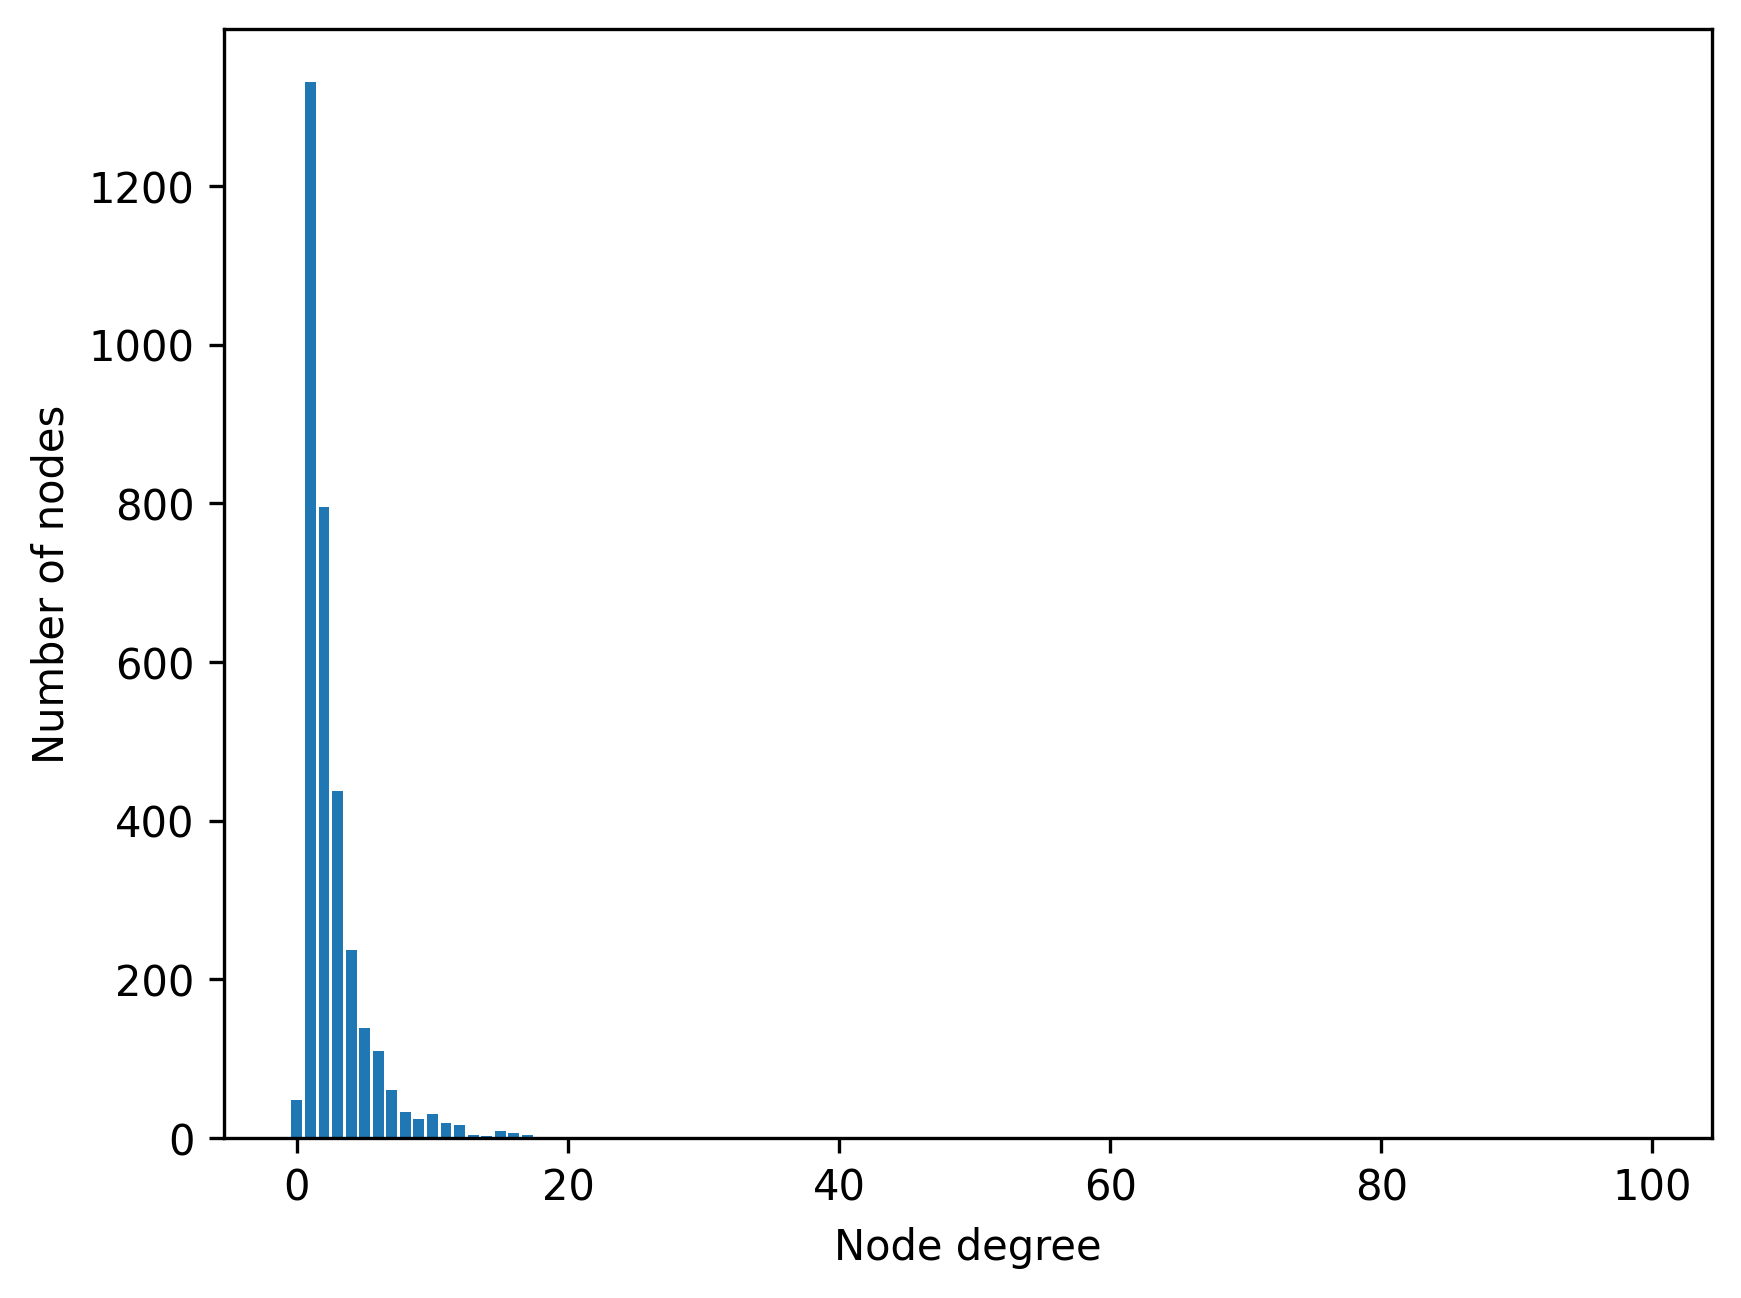

In [54]:
import matplotlib.pyplot as plt
from torch_geometric.utils import degree
from collections import Counter
degrees = degree(dataset[0].edge_index[0]).numpy()
numbers = Counter(degrees)
fig, ax = plt.subplots(dpi=300)
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
plt.bar(numbers.keys(), numbers.values())

here it looks like a typical heavy-tailed distribution but with a twist: some nodes have a degree of zero! in other words, they are not connected to any other node. we can assume that they will be much more difficult to classify than the rest.

In [55]:
gat = GAT(dataset.num_features, 16, dataset.num_classes)
gat.fit(data, epochs = 100)

Epoch   0 | Train loss: 1.781 | Train acc: 24.17% | Val loss: 1.78 | Val acc: 22.60%
Epoch  20 | Train loss: 0.161 | Train acc: 99.17% | Val loss: 1.16 | Val acc: 62.80%
Epoch  40 | Train loss: 0.135 | Train acc: 97.50% | Val loss: 1.29 | Val acc: 59.40%
Epoch  60 | Train loss: 0.126 | Train acc: 98.33% | Val loss: 1.19 | Val acc: 61.60%
Epoch  80 | Train loss: 0.163 | Train acc: 96.67% | Val loss: 1.13 | Val acc: 63.80%
Epoch 100 | Train loss: 0.150 | Train acc: 95.83% | Val loss: 1.13 | Val acc: 62.40%


In [56]:
acc = gat.test(data)
print(f"GAT test accuracy: {acc * 100:.2f}%")

GAT test accuracy: 66.90%


previously we speculated that poorly connected nodes might negatively impact performance. we can verify this hypothesis by plotting the average accuracy score for each node degree:

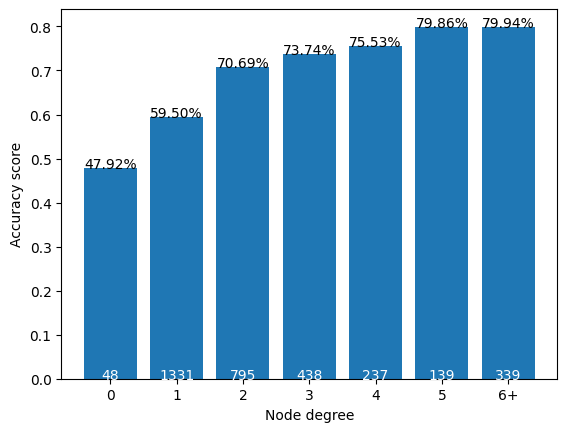

In [57]:
out = gat(data.x, data.edge_index) # get the model's classifications
degrees = degree(data.edge_index[0]).numpy() # calculate teh degree of each node.

# we store the accuracy scores and sample sizes
accuracies, sizes = [], []

for i in range(6):
    mask = np.where(degrees == i)[0]
    accuracies.append(accuracy(out.argmax(dim = 1)[mask], data.y[mask]))
    sizes.append(len(mask))


# we repeat thsi process for every node with a degree higher than 5
mask = np.where(degrees > 5)[0]
accuracies.append(accuracy(out.argmax(dim = 1)[mask], data.y[mask]))
sizes.append(len(mask))

# Bar plot
fig, ax = plt.subplots()
ax.set_xlabel('Node degree')
ax.set_ylabel('Accuracy score')
plt.bar(['0','1','2','3','4','5','6+'], accuracies)
for i in range(0, 7):
    plt.text(i, accuracies[i], f'{accuracies[i]*100:.2f}%', ha='center', color='black')
for i in range(0, 7):
    plt.text(i, accuracies[i]//2, sizes[i], ha='center', color='white')